# Colab: Phase 1 Zahid Top-50 Pretrain (Gemma-4 26B A4B)

This notebook only does **Phase 1**: Zahid→canonical Top-50 pretraining.

Outputs:
- local stage-1 LoRA adapter under `WORK_DIR / phase1_zahid_pretrain_outputs/stage1_adapter`
- optional Drive copy at `/content/drive/MyDrive/asl/stage1_adapter`
- optional Hugging Face push to `AlexD281/asl-gemma4-26b-a4b-zahid-pretrain-lora`

Run Phase 2 in `12_colab_gemma4_26b_wlasl_phase2_continue.ipynb` from a fresh Colab runtime.


In [1]:
# Set Hugging Face token for this Colab runtime
from getpass import getpass
from huggingface_hub import login

HF_TOKEN = getpass('Enter your HF token (input hidden): ').strip()
login(token=HF_TOKEN, add_to_git_credential=False)
print('Hugging Face login set for this runtime')


Enter your HF token (input hidden): ··········
Hugging Face login set for this runtime


In [2]:
# 1) Install deps (fresh Colab runtime)
import os
os.environ["UNSLOTH_DISABLE_STATISTICS"] = "1"

!pip -q install --upgrade pip
!pip -q install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"     trl peft accelerate datasets huggingface_hub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 86.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
from pathlib import Path

# Resolve repo root when running from Colab notebooks/ paths

def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd] + list(cwd.parents)
    for c in candidates:
        if (c / '.git').exists() or (c / 'pyproject.toml').exists() or (c / 'README.md').exists():
            return c
    return cwd

REPO_ROOT = resolve_repo_root()

# Core model/run config
HF_NAMESPACE = "AlexD281"
BASE_MODEL = "unsloth/gemma-4-26B-A4B-it"

STAGE1_RUN_NAME = "asl-gemma4-26b-a4b-zahid-pretrain-lora"
STAGE2_RUN_NAME = "asl-gemma4-26b-a4b-zahid-then-wlasl-top50-lora"
STAGE1_ADAPTER_REPO_ID = f"{HF_NAMESPACE}/{STAGE1_RUN_NAME}"
STAGE2_ADAPTER_REPO_ID = f"{HF_NAMESPACE}/{STAGE2_RUN_NAME}"

# Data contract
NUM_FRAMES = 30
IMAGE_SIZE = 448

# Workspace
WORK_DIR = Path("/content/asl_gemma4_26b")
DATA_DIR = WORK_DIR / "data"
OUTPUT_DIR = WORK_DIR / "outputs"
PRED_DIR = WORK_DIR / "predictions"
PUSH_TO_HUB_PHASE2 = False
for p in [DATA_DIR, OUTPUT_DIR, PRED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

PHASE1_DIR = DATA_DIR / 'phase1_zahid_top50'
PHASE1_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("WORK_DIR:", WORK_DIR)
print("PHASE1_DIR:", PHASE1_DIR)
print("Base model:", BASE_MODEL)
print("Stage-1 adapter repo:", STAGE1_ADAPTER_REPO_ID)
print("Stage-2 adapter repo:", STAGE2_ADAPTER_REPO_ID)



Repo root: /content
WORK_DIR: /content/asl_gemma4_26b
PHASE1_DIR: /content/asl_gemma4_26b/data/phase1_zahid_top50
Base model: unsloth/gemma-4-26B-A4B-it
Stage-1 adapter repo: AlexD281/asl-gemma4-26b-a4b-zahid-pretrain-lora
Stage-2 adapter repo: AlexD281/asl-gemma4-26b-a4b-zahid-then-wlasl-top50-lora


In [4]:
# Mount Google Drive for zip + labels paths
from google.colab import drive

drive.mount('/content/drive')
print("Drive mounted")



Mounted at /content/drive
Drive mounted


In [5]:
# Fail-fast contract checks: canonical Top-50 allowlist only

top50_labels_file = Path(globals().get("TOP50_LABELS_FILE", "/content/drive/MyDrive/asl/video_finetune/top50/labels.txt"))
assert top50_labels_file.exists(), (
    f"Missing Top-50 labels file: {top50_labels_file}. "
    "Set TOP50_LABELS_FILE to a valid path in Drive."
)

top50_labels = [l.strip().lower() for l in top50_labels_file.read_text().splitlines() if l.strip()]
assert len(top50_labels) == 50, f"Expected 50 Top-50 labels, found {len(top50_labels)}"
assert len(set(top50_labels)) == 50, "Top-50 labels must be unique"
top50_set = set(top50_labels)

print("Allowlist checks passed")
print("Top-50 labels:", len(top50_labels))
print("Labels file:", top50_labels_file)



Allowlist checks passed
Top-50 labels: 50
Labels file: /content/drive/MyDrive/asl/video_finetune/top50/labels.txt


In [6]:
# Phase-1 minimal zip-first: unzip bundle and set PHASE1_DIR
import zipfile
from pathlib import Path

PHASE1_ZIP_PATH = Path(globals().get('PHASE1_ZIP_PATH', '/content/drive/MyDrive/asl/phase1_zahid_top50_bundle.zip'))
PHASE1_DIR = Path('/content/asl_gemma4_26b_zahid_wlasl_unified/data/phase1_zahid_top50')
PHASE1_DIR.mkdir(parents=True, exist_ok=True)

if not PHASE1_ZIP_PATH.exists():
    raise FileNotFoundError(f"Missing zip: {PHASE1_ZIP_PATH}")

with zipfile.ZipFile(PHASE1_ZIP_PATH) as zf:
    zf.extractall(PHASE1_DIR)

# Robust resolver: find manifest folder + frames folder recursively after unzip
frames_name = f"frames_{int(NUM_FRAMES)}x{int(IMAGE_SIZE)}"
required = ['train.jsonl', 'val.jsonl', 'test.jsonl']

def has_required_manifests(d: Path) -> bool:
    return all((d / f).exists() for f in required)

manifest_candidates = sorted({p.parent for p in PHASE1_DIR.rglob('train.jsonl') if has_required_manifests(p.parent)}, key=lambda p: len(p.parts))
if has_required_manifests(PHASE1_DIR):
    manifest_candidates = [PHASE1_DIR] + [p for p in manifest_candidates if p != PHASE1_DIR]

if not manifest_candidates:
    raise FileNotFoundError(f"Could not find folder containing train/val/test manifests under {PHASE1_DIR}")

PHASE1_DIR = manifest_candidates[0]

# Prefer exact frames_{N}x{SIZE}; fallback to sibling frames/ if provided by bundle
preferred_frames = PHASE1_DIR / frames_name
fallback_frames = PHASE1_DIR / 'frames'
if preferred_frames.exists():
    PHASE1_FRAMES_DIR = preferred_frames
elif fallback_frames.exists():
    PHASE1_FRAMES_DIR = fallback_frames
else:
    # Last fallback: find the nearest matching frames dir below manifest root
    frame_hits = [d for d in PHASE1_DIR.rglob('*') if d.is_dir() and d.name in {frames_name, 'frames'}]
    if not frame_hits:
        raise FileNotFoundError(f"Missing frames folder ({frames_name} or frames) under {PHASE1_DIR}")
    PHASE1_FRAMES_DIR = sorted(frame_hits, key=lambda p: len(p.parts))[0]

for req in required:
    if not (PHASE1_DIR / req).exists():
        raise FileNotFoundError(f"Missing {req} in {PHASE1_DIR}")

print('PHASE1_DIR:', PHASE1_DIR)
print('PHASE1_FRAMES_DIR:', PHASE1_FRAMES_DIR)



PHASE1_DIR: /content/asl_gemma4_26b_zahid_wlasl_unified/data/phase1_zahid_top50/data/phase1_zahid_top50
PHASE1_FRAMES_DIR: /content/asl_gemma4_26b_zahid_wlasl_unified/data/phase1_zahid_top50/data/phase1_zahid_top50/frames_30x448


In [7]:
# Phase-1 minimal preprocessing: rebuild frame paths, skip bad rows
import json
from pathlib import Path

N_FRAMES = int(NUM_FRAMES)
FRAME_SIZE = int(IMAGE_SIZE)
# Gemma-4 26B vision context is effectively capped at 2048 by backend/runtime;
# keep image count small enough to avoid image-token truncation mismatch.
MAX_IMAGES_PER_SAMPLE = int(globals().get('MAX_IMAGES_PER_SAMPLE', 6))
if MAX_IMAGES_PER_SAMPLE < 1:
    raise ValueError('MAX_IMAGES_PER_SAMPLE must be >= 1')
FRAMES_ROOT = Path(globals().get('PHASE1_FRAMES_DIR', Path(PHASE1_DIR) / f"frames_{N_FRAMES}x{FRAME_SIZE}"))

train_manifest = Path(PHASE1_DIR) / 'train.jsonl'
val_manifest = Path(PHASE1_DIR) / 'val.jsonl'
test_manifest = Path(PHASE1_DIR) / 'test.jsonl'

top50_labels_file = Path(globals().get('TOP50_LABELS_FILE', '/content/drive/MyDrive/asl/video_finetune/top50/labels.txt'))
labels = [x.strip().lower() for x in top50_labels_file.read_text(encoding='utf-8').splitlines() if x.strip()]
ALLOW = set(labels)


def load_jsonl(path: Path):
    return [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]


def build_split(manifest_path: Path, split_name: str):
    rows = load_jsonl(manifest_path)
    out, dropped = [], 0
    for r in rows:
        sid = str(r.get('sample_id', '')).strip()
        gloss = ' '.join(str(r.get('gloss', '')).strip().lower().split())
        if not sid or gloss not in ALLOW:
            dropped += 1
            continue

        all_frame_paths = [str(FRAMES_ROOT / split_name / sid / f"frame_{i:03d}.jpg") for i in range(N_FRAMES)]
        if not all(Path(fp).exists() for fp in all_frame_paths):
            dropped += 1
            continue

        if len(all_frame_paths) <= MAX_IMAGES_PER_SAMPLE:
            frame_paths = all_frame_paths
        else:
            # Evenly subsample to keep temporal coverage while respecting token budget
            idxs = [round(i * (len(all_frame_paths) - 1) / (MAX_IMAGES_PER_SAMPLE - 1)) for i in range(MAX_IMAGES_PER_SAMPLE)]
            frame_paths = [all_frame_paths[i] for i in idxs]

        out.append({
            'sample_id': sid,
            'split': split_name,
            'label': gloss,
            'frame_paths': frame_paths,
            'messages': [
                {
                    'role': 'user',
                    'content': [
                        {'type': 'text', 'text': 'Identify the ASL sign shown across these frames. Return exactly one gloss label from the approved list.'},
                        *[{'type': 'image', 'image': p} for p in frame_paths],
                    ],
                },
                {'role': 'assistant', 'content': [{'type': 'text', 'text': gloss}]},
            ],
        })

    print(f"{split_name}: kept={len(out)} dropped={dropped}")
    return out


phase1_train_data = build_split(train_manifest, 'train')
phase1_val_data = build_split(val_manifest, 'val')
phase1_test_data = build_split(test_manifest, 'test')

if len(phase1_train_data) == 0:
    raise RuntimeError('No valid phase-1 train rows after filtering.')

# helper kept for phase-2 eval cell prerequisite check
ALLOWED_LABELS = sorted(ALLOW)
ALLOWED_LABELS_SET = set(ALLOWED_LABELS)
def normalize_text(s: str) -> str:
    return ' '.join(str(s).strip().lower().split())
def strict_normalize_label(raw_pred: str) -> str:
    x = normalize_text(raw_pred)
    return x if x in ALLOWED_LABELS_SET else '__invalid__'

print('phase1_train_data:', len(phase1_train_data))
print('phase1_val_data:', len(phase1_val_data))
print('phase1_test_data:', len(phase1_test_data))
print('MAX_IMAGES_PER_SAMPLE:', MAX_IMAGES_PER_SAMPLE)



train: kept=2022 dropped=52
val: kept=256 dropped=3
test: kept=256 dropped=3
phase1_train_data: 2022
phase1_val_data: 256
phase1_test_data: 256
MAX_IMAGES_PER_SAMPLE: 6


In [8]:
# Phase-1: Gemma-4-26B-A4B LoRA trainer scaffold (gated for Colab)
import torch
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTConfig, SFTTrainer

required_vars = ['WORK_DIR', 'phase1_train_data', 'phase1_val_data']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing prerequisites: {missing}. Run phase-1 formatting cell first.")

BASE_MODEL = globals().get('BASE_MODEL', 'google/gemma-4-26B-A4B-it')
PHASE1_DIR = Path(PHASE1_DIR)
PHASE1_OUTPUT_DIR = Path(WORK_DIR) / 'phase1_zahid_pretrain_outputs'
PHASE1_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
STAGE1_ADAPTER_REPO = "AlexD281/asl-gemma4-26b-a4b-zahid-pretrain-lora"
RUN_PHASE1_TRAIN = True
PUSH_TO_HUB = True

if not torch.cuda.is_available():
    raise RuntimeError('CUDA GPU is required for 26B QLoRA training.')
gpu_name = torch.cuda.get_device_name(0)
gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
print(f'GPU: {gpu_name} | VRAM: {gpu_mem_gb:.1f} GB | BASE_MODEL: {BASE_MODEL}')

try:
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name=BASE_MODEL,
        load_in_4bit=True,
        use_gradient_checkpointing='unsloth',
        device_map={'': 0},
    )
except ValueError as e:
    msg = str(e)
    if 'dispatched on the CPU or the disk' in msg:
        raise RuntimeError(
            f'Insufficient VRAM for {BASE_MODEL} on {gpu_name} ({gpu_mem_gb:.1f} GB). '
            'Use an A100/H100 class runtime for 26B, or switch BASE_MODEL to a smaller Gemma-4 variant.'
        ) from e
    raise

model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=16,
    lora_alpha=16,
    lora_dropout=0,
    bias='none',
    random_state=3407,
)

cuda_available = torch.cuda.is_available()
bf16_supported = bool(cuda_available and torch.cuda.is_bf16_supported())

# 30 images can require ~7680 image tokens; keep sequence cap safely above that
phase1_max_seq_length = int(globals().get('PHASE1_MAX_SEQ_LENGTH', 8192))
if phase1_max_seq_length < 8192:
    raise ValueError(f'PHASE1_MAX_SEQ_LENGTH too small: {phase1_max_seq_length}. Use >= 8192 for 30-frame inputs.')

phase1_sft_kwargs = dict(
    output_dir=str(PHASE1_OUTPUT_DIR),
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=3e-4,
    num_train_epochs=2,
    logging_steps=10,
    save_strategy='steps',
    save_steps=50,
    evaluation_strategy='steps',
    eval_steps=50,
    bf16=bf16_supported,
    fp16=bool(cuda_available and not bf16_supported),
    gradient_checkpointing=True,
    remove_unused_columns=False,
    dataset_text_field='',
    max_seq_length=phase1_max_seq_length,
    dataset_kwargs={'skip_prepare_dataset': True},
    report_to='none',
)

try:
    phase1_train_args = SFTConfig(**phase1_sft_kwargs)
except TypeError as e:
    if 'evaluation_strategy' in str(e):
        phase1_sft_kwargs['eval_strategy'] = phase1_sft_kwargs.pop('evaluation_strategy')
        phase1_train_args = SFTConfig(**phase1_sft_kwargs)
    else:
        raise
print('phase1_max_seq_length:', phase1_max_seq_length)

phase1_trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=UnslothVisionDataCollator(model, tokenizer),
    train_dataset=phase1_train_data,
    eval_dataset=phase1_val_data,
    args=phase1_train_args,
)

print('Phase-1 scaffold ready')
print('Output dir:', PHASE1_OUTPUT_DIR)
print('RUN_PHASE1_TRAIN:', RUN_PHASE1_TRAIN, '| PUSH_TO_HUB:', PUSH_TO_HUB)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
GPU: NVIDIA A100-SXM4-80GB | VRAM: 79.3 GB | BASE_MODEL: unsloth/gemma-4-26B-A4B-it
==((====))==  Unsloth 2026.5.7: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1013 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

Unsloth: Detected MoE model with num_experts = 128 and target_modules = '(?:.*?(?:vision|image|visual|patch|language|text).*?(?:self_attn|attention|attn|mlp|feed_forward|ffn|dense).*?(?:k_proj|q_proj|v_proj|o_proj|gate_proj|up_proj|down_proj|proj|linear).*?)|(?:\\bmodel\\.layers\\.[\\d]{1,}\\.(?:self_attn|attention|attn|mlp|feed_forward|ffn|dense)\\.(?:(?:k_proj|q_proj|v_proj|o_proj|gate_proj|up_proj|down_proj|proj|linear)))'. Enabling LoRA on MoE parameters: ['experts.gate_up_proj', 'experts.down_proj']
phase1_max_seq_length: 8192
Unsloth: Model does not have a default image size - using 512
Unsloth: You set `max_seq_length` as 8192 but the maximum the model supports is 2048. We shall reduce it.
Phase-1 scaffold ready
Output dir: /content/asl_gemma4_26b/phase1_zahid_pretrain_outputs
RUN_PHASE1_TRAIN: True | PUSH_TO_HUB: True


In [9]:
# Phase-1: gated train + adapter save/push
if 'phase1_trainer' not in globals():
    raise RuntimeError('Missing trainer. Run phase-1 scaffold cell first.')

PHASE1_ADAPTER_LOCAL_PATH = PHASE1_OUTPUT_DIR / 'stage1_adapter'
PHASE1_ADAPTER_DRIVE_PATH = Path(globals().get('PHASE1_ADAPTER_DRIVE_PATH', '/content/drive/MyDrive/asl/stage1_adapter'))
COPY_PHASE1_ADAPTER_TO_DRIVE = bool(globals().get('COPY_PHASE1_ADAPTER_TO_DRIVE', True))

if RUN_PHASE1_TRAIN:
    train_result = phase1_trainer.train()
    phase1_trainer.model.save_pretrained(str(PHASE1_ADAPTER_LOCAL_PATH))
    tokenizer.save_pretrained(str(PHASE1_ADAPTER_LOCAL_PATH))

    if COPY_PHASE1_ADAPTER_TO_DRIVE:
        import shutil
        if PHASE1_ADAPTER_DRIVE_PATH.exists():
            shutil.rmtree(PHASE1_ADAPTER_DRIVE_PATH)
        shutil.copytree(PHASE1_ADAPTER_LOCAL_PATH, PHASE1_ADAPTER_DRIVE_PATH)
        print('Copied stage-1 adapter to Drive:', PHASE1_ADAPTER_DRIVE_PATH)

    if PUSH_TO_HUB:
        phase1_trainer.model.push_to_hub(STAGE1_ADAPTER_REPO)
        tokenizer.push_to_hub(STAGE1_ADAPTER_REPO)
else:
    print('RUN_PHASE1_TRAIN is False; skipping training.')

print('PHASE1_ADAPTER_LOCAL_PATH:', PHASE1_ADAPTER_LOCAL_PATH)
print('PHASE1_ADAPTER_DRIVE_PATH:', PHASE1_ADAPTER_DRIVE_PATH)
print('STAGE1_ADAPTER_REPO:', STAGE1_ADAPTER_REPO)


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,022 | Num Epochs = 2 | Total steps = 506
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 505,429,248 of 26,311,363,120 (1.92% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
50,0.079477,0.352652
100,0.012949,0.096761
150,0.011331,0.090753
200,0.010124,0.087530
250,0.009464,0.069160
300,0.005492,0.047932
350,0.005322,0.040086
400,0.005374,0.037078
450,0.003287,0.032559
500,0.003839,0.028410


Unsloth: Not an error, but Gemma4ForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient
Unsloth: Restored added_tokens_decoder metadata in /content/asl_gemma4_26b/phase1_zahid_pretrain_outputs/checkpoint-50/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/asl_gemma4_26b/phase1_zahid_pretrain_outputs/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/asl_gemma4_26b/phase1_zahid_pretrain_outputs/checkpoint-150/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/asl_gemma4_26b/phase1_zahid_pretrain_outputs/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/asl_gemma4_26b/phase1_zahid_pretrain_outputs/checkpoint-250/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metad

Copied stage-1 adapter to Drive: /content/drive/MyDrive/asl/stage1_adapter


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp7pjaui8w/tokenizer.json: 100%|##########| 32.2MB / 32.2MB            

No files have been modified since last commit. Skipping to prevent empty commit.


PHASE1_ADAPTER_LOCAL_PATH: /content/asl_gemma4_26b/phase1_zahid_pretrain_outputs/stage1_adapter
PHASE1_ADAPTER_DRIVE_PATH: /content/drive/MyDrive/asl/stage1_adapter
STAGE1_ADAPTER_REPO: AlexD281/asl-gemma4-26b-a4b-zahid-pretrain-lora


In [10]:
# Phase-1: gated eval diagnostics (strict allowlist normalization)
import json

RUN_PHASE1_EVAL = True
PHASE1_EVAL_MAX_SAMPLES = 200

if RUN_PHASE1_EVAL:
    if 'model' not in globals() or 'tokenizer' not in globals():
        raise RuntimeError('Missing model/tokenizer for eval.')

    FastVisionModel.for_inference(model)

    def predict_label(sample: dict) -> str:
        user_msg = [m for m in sample['messages'] if m['role'] == 'user'][0]
        prompt_msgs = [user_msg]
        inputs = tokenizer.apply_chat_template(
            prompt_msgs,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors='pt',
        )
        # apply_chat_template can return a BatchFeature/BatchEncoding, which is
        # dict-like and has .to(...), but does not have a tensor .shape.
        if hasattr(inputs, 'to'):
            inputs = inputs.to(model.device)
        else:
            inputs = {k: v.to(model.device) if hasattr(v, 'to') else v for k, v in inputs.items()}
        prompt_len = int(inputs['input_ids'].shape[-1])
        out = model.generate(**inputs, max_new_tokens=8, do_sample=False)
        gen_tokens = out[0][prompt_len:]
        pred_text = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()
        pred_text = pred_text.split('\n')[0].strip().strip(" .,:;!'\"")
        return strict_normalize_label(pred_text)

    eval_summary = {}
    for split_name, data in [('val', phase1_val_data), ('test', phase1_test_data)]:
        subset = data[:PHASE1_EVAL_MAX_SAMPLES]
        if not subset:
            raise RuntimeError(f"No samples available for split={split_name}")
        total = len(subset)
        correct = 0
        invalid = 0
        for sample in subset:
            pred = predict_label(sample)
            gold = sample['label']
            invalid += int(pred == '__invalid__')
            correct += int(pred == gold)

        metrics = {
            'samples': total,
            'accuracy': correct / total,
            'invalid_rate': invalid / total,
            'correct': correct,
            'invalid': invalid,
        }
        eval_summary[split_name] = metrics
        print(split_name, metrics)

    eval_out_path = PHASE1_DIR / 'phase1_eval_summary.json'
    eval_out_path.write_text(json.dumps(eval_summary, indent=2, ensure_ascii=False), encoding='utf-8')
    print('Wrote eval summary:', eval_out_path)

    if bool(globals().get('PUSH_TO_HUB', False)):
        from huggingface_hub import HfApi
        api = HfApi()
        repo_id = globals().get('STAGE1_ADAPTER_REPO', globals().get('STAGE1_ADAPTER_REPO_ID'))
        if not repo_id:
            raise RuntimeError('PUSH_TO_HUB=True but no STAGE1_ADAPTER_REPO/STAGE1_ADAPTER_REPO_ID is configured.')
        api.create_repo(repo_id, repo_type='model', private=True, exist_ok=True)
        api.upload_file(
            path_or_fileobj=str(eval_out_path),
            path_in_repo='metrics/phase1_eval_summary.json',
            repo_id=repo_id,
            repo_type='model',
            commit_message='Add phase-1 eval metrics',
        )
        print('Uploaded eval metrics to Hub:', f'{repo_id}/metrics/phase1_eval_summary.json')
else:
    print('RUN_PHASE1_EVAL is False; skipping eval diagnostics.')


val {'samples': 200, 'accuracy': 0.645, 'invalid_rate': 0.0, 'correct': 129, 'invalid': 0}
test {'samples': 200, 'accuracy': 0.625, 'invalid_rate': 0.0, 'correct': 125, 'invalid': 0}
Wrote eval summary: /content/asl_gemma4_26b_zahid_wlasl_unified/data/phase1_zahid_top50/data/phase1_zahid_top50/phase1_eval_summary.json
Uploaded eval metrics to Hub: AlexD281/asl-gemma4-26b-a4b-zahid-pretrain-lora/metrics/phase1_eval_summary.json


Loading metrics from: /content/asl_gemma4_26b/phase1_zahid_pretrain_outputs/checkpoint-506/trainer_state.json


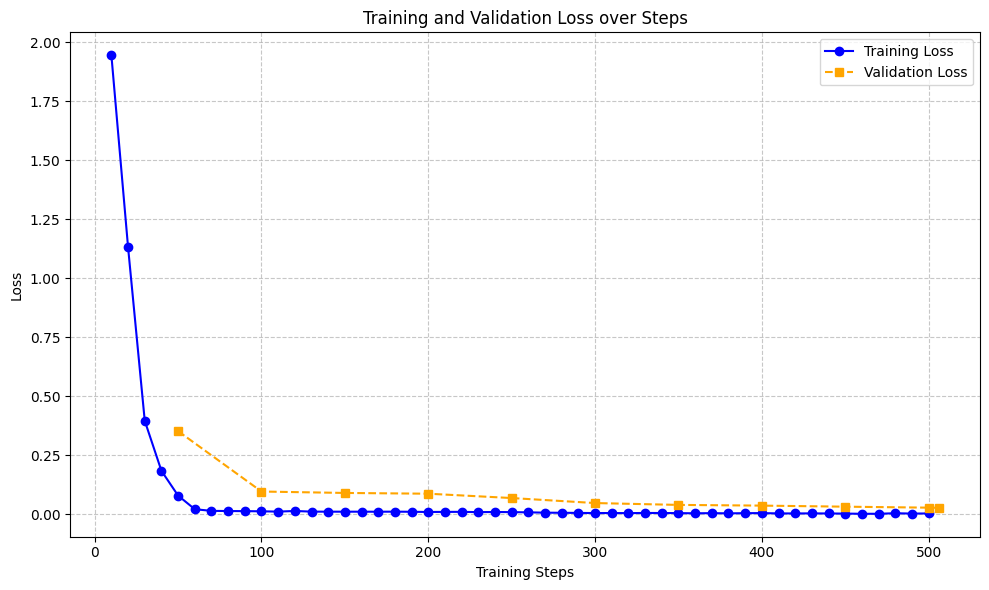

In [11]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

# Point to your output directory
output_dir = Path('/content/asl_gemma4_26b/phase1_zahid_pretrain_outputs')
state_files = list(output_dir.glob('checkpoint-*/trainer_state.json'))

if not state_files:
    print("No trainer_state.json found in checkpoints.")
else:
    # Find the latest checkpoint state file
    latest_state_file = max(state_files, key=lambda p: int(p.parent.name.split('-')[1]))
    print(f"Loading metrics from: {latest_state_file}")

    with open(latest_state_file, 'r') as f:
        state = json.load(f)

    log_history = state.get('log_history', [])

    train_steps, train_loss = [], []
    eval_steps, eval_loss = [], []

    for log in log_history:
        if 'loss' in log and 'step' in log:
            train_steps.append(log['step'])
            train_loss.append(log['loss'])
        elif 'eval_loss' in log and 'step' in log:
            eval_steps.append(log['step'])
            eval_loss.append(log['eval_loss'])

    # Plotting
    plt.figure(figsize=(10, 6))
    if train_loss:
        plt.plot(train_steps, train_loss, label='Training Loss', marker='o', linestyle='-', color='blue')
    if eval_loss:
        plt.plot(eval_steps, eval_loss, label='Validation Loss', marker='s', linestyle='--', color='orange')

    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss over Steps')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()